[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vonKleve/csci-e222-final-project/blob/master/qa/01-bioclinicalbert.ipynb)

# Fine Tuning Bio_ClinicalBERT for Medical Multiple Choice QA (MedQA)

## Description
This notebook fine-tunes `emilyalsentzer/Bio_ClinicalBERT` on the `GBaker/MedQA-USMLE-4-options` dataset.

MedQA represents questions from the USMLE (US Medical Licensing Examination). Multiple Choice QA requires transforming the input so that the model scores each of the 4 possible answers independently. I pass the question + option combination through the model four times per batch item, and the model uses a linear classifier on top of the `[CLS]` token to output a single score per option. The scores are then passed through a softmax to determine the predicted answer.

**To load this model from the Hub:**
```python
import torch
from transformers import AutoTokenizer, AutoModelForMultipleChoice

model_id = "alexd063/bio-clinicalbert-finetuned-medqa"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForMultipleChoice.from_pretrained(model_id)

question = "A 60-year-old man comes to the physician because of flank pain... Which of the following is most likely?"
options = [
    "Dermal IgA deposition on skin biopsy",
    "Crescent-shape extracapillary cell proliferation",
    "Mesangial IgA deposits on renal biopsy",
    "Urinary eosinophils"
]

inputs = tokenizer([[question, opt] for opt in options], return_tensors="pt", padding=True)
inputs = {k: v.unsqueeze(0) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=1).item()

print(f"Predicted Answer: {options[prediction]}")

In [1]:
%%capture
!pip install transformers datasets evaluate scikit-learn matplotlib seaborn accelerate torch numpy pandas
!pip install --upgrade transformers

In [2]:
import os
# Suppress all tqdm/HuggingFace progress bars before any library is imported
os.environ["TQDM_DISABLE"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BARS"] = "1"

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Optional, Union
from sklearn.metrics import accuracy_score, f1_score

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from transformers.tokenization_utils_base import PreTrainedTokenizerBase
from huggingface_hub import notebook_login


In [4]:
import os
os.environ["TQDM_DISABLE"] = "1"

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

from datasets import disable_progress_bars
disable_progress_bars()

from huggingface_hub.utils import disable_progress_bars as hub_disable_progress_bars
hub_disable_progress_bars()

In [5]:
PUSH_TO_HUB = True  # Set to False to skip login and hub push

if PUSH_TO_HUB:
    notebook_login()

In [6]:
import time
notebook_start_time = time.time()


## 1. Hyperparameters

* **Batch Size (`4`)**: Multiple Choice tasks are memory intensive. For every question, I pass 4 sequences (Question + Option A, B, C, D). A batch size of 4 essentially means `4 x 4 = 16` distinct sequences of `MAX_LENGTH` are processed simultaneously. To avoid Out-Of-Memory (OOM) issues I limit batch size to 4.
* **Learning Rate (`4e-5`)**: slightly higher learning rate so that the new classification head can learn efficiently to analyze `[CLS]` token.
* **Scheduler (`Cosine` with `10% Warmup`)**: Warmup prevents the pre trained weights of `Bio_ClinicalBERT`
from being influenced by the randomly initialized classification head during the first iterations.
* **Early Stopping**: tracks `accuracy`, has patience of 2 epochs, saves time during fine tuning.

In [7]:
class Config:
    MODEL_ID = "emilyalsentzer/Bio_ClinicalBERT"
    DATASET_ID = "GBaker/MedQA-USMLE-4-options"
    HUB_REPO_ID = "alexd063/bio-clinicalbert-finetuned-medqa"

    MAX_LENGTH = 512
    BATCH_SIZE = 4
    EPOCHS = 10
    LEARNING_RATE = 4e-5
    WARMUP_RATIO = 0.10
    WEIGHT_DECAY = 0.01

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()

## 2. Data loading & preprocessing
The MedQA dataset contains only `train` and `test` splits. I create `validation` set by holding out 10% of the `train` set.

For Multiple Choice, we must "flatten" the data for the tokenizer (creating a list of `[Question, Option]` pairs), and then "un-flatten" it back into groups of 4 so the model knows which 4 options belong to the same question.

In [8]:
dataset = load_dataset(config.DATASET_ID)

# jic if the dataset is replaced, normally MedQA does not contain validation set
if "validation" not in dataset:
    print("Creating validation split from train (10%)")
    split_ds = dataset["train"].train_test_split(test_size=0.1, seed=42)
    dataset["train"] = split_ds["train"]
    dataset["validation"] = split_ds["test"]

print("Dataset statistics")
for split in dataset.keys():
    print(f"{split.capitalize()} size: {len(dataset[split])} samples")

# tokenization
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_ID)

def preprocess_function(examples):
    # repeat each question 4 times (bc 4 answers)
    first_sentences = [[context] * 4 for context in examples["question"]]
    second_sentences = []
    labels = []

    for options, answer_idx in zip(examples["options"], examples["answer_idx"]):
        # sort options to ensure A, B, C, D order
        sorted_keys = sorted(options.keys())
        opts = [options[key] for key in sorted_keys]
        second_sentences.append(opts)

        # label -> id correspondence
        labels.append(sorted_keys.index(answer_idx))

    first_sentences = sum(first_sentences, [])
    second_sentences = sum(second_sentences, [])

    tokenized_examples = tokenizer(
        first_sentences,
        second_sentences,
        truncation=True,
        truncation_side="left",
        max_length=config.MAX_LENGTH,
        padding=False
    )

    # unflatten to group into sets of 4 choices per question
    result = {k: [v[i : i + 4] for i in range(0, len(v), 4)] for k, v in tokenized_examples.items()}
    result["label"] = labels

    return result

tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Creating validation split from train (10%)
Dataset statistics
Train size: 9160 samples
Test size: 1273 samples
Validation size: 1018 samples


## 3. Metrics
  * `Accuracy`: % of questions answered correctly.
  * `Macro F1`: average of F1 class scores.
  * `Expected Calibration Error (ECE)`: measures whether the model's confidence scores align with its actual accuracy. A low ECE means if the model is 90% confident, it is correct about 90% of the time.

In [9]:
@dataclass
class DataCollatorForMultipleChoice:
    tokenizer: PreTrainedTokenizerBase
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None

    def __call__(self, features):
        label_name = "label" if "label" in features[0].keys() else "labels"
        labels = [feature.pop(label_name) for feature in features]
        batch_size = len(features)
        num_choices = len(features[0]["input_ids"])

        # Flatten features for padding
        flattened_features = [
            [{k: v[i] for k, v in feature.items()} for i in range(num_choices)] for feature in features
        ]
        flattened_features = sum(flattened_features, [])

        batch = self.tokenizer.pad(
            flattened_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        # Reshape to (batch_size, num_choices, max_seq_length)
        batch = {k: v.view(batch_size, num_choices, -1) for k, v in batch.items()}
        batch["labels"] = torch.tensor(labels, dtype=torch.int64)
        return batch


def compute_ece(probs, labels, n_bins=10):
    """Calculates the Expected Calibration Error (ECE)."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels)

    ece = 0.0
    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i+1]

        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return float(ece)


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Softmax across the 4 options to get probabilities for ECE
    probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "ece": compute_ece(probs, labels)
    }

## 4. Model initialization & training
Using `AutoModelForMultipleChoice` with a new classification head.

In [10]:

model = AutoModelForMultipleChoice.from_pretrained(config.MODEL_ID)

training_args = TrainingArguments(
    output_dir="./bio-clinicalbert-medqa",
    eval_strategy="epoch",
    save_strategy="epoch",
    # ---------------------------------
    # training rate & length
    # ---------------------------------
    learning_rate=config.LEARNING_RATE,
    warmup_ratio=config.WARMUP_RATIO,
    lr_scheduler_type="cosine",
    per_device_train_batch_size=config.BATCH_SIZE,
    per_device_eval_batch_size=config.BATCH_SIZE,
    num_train_epochs=config.EPOCHS,
    weight_decay=config.WEIGHT_DECAY,
    # ---------------------------------
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    hub_model_id=config.HUB_REPO_ID if PUSH_TO_HUB else None
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorForMultipleChoice(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

trainer.save_model("./bio-clinicalbert-medqa-final")


{'loss': '1.385', 'grad_norm': '20.06', 'learning_rate': '8.559e-07', 'epoch': '0.02183'}
{'loss': '1.412', 'grad_norm': '9.054', 'learning_rate': '1.729e-06', 'epoch': '0.04367'}
{'loss': '1.416', 'grad_norm': '9.738', 'learning_rate': '2.603e-06', 'epoch': '0.0655'}
{'loss': '1.429', 'grad_norm': '17.91', 'learning_rate': '3.476e-06', 'epoch': '0.08734'}
{'loss': '1.423', 'grad_norm': '7.625', 'learning_rate': '4.349e-06', 'epoch': '0.1092'}
{'loss': '1.405', 'grad_norm': '10.6', 'learning_rate': '5.223e-06', 'epoch': '0.131'}
{'loss': '1.387', 'grad_norm': '7.421', 'learning_rate': '6.096e-06', 'epoch': '0.1528'}
{'loss': '1.396', 'grad_norm': '8.842', 'learning_rate': '6.969e-06', 'epoch': '0.1747'}
{'loss': '1.394', 'grad_norm': '11.3', 'learning_rate': '7.843e-06', 'epoch': '0.1965'}
{'loss': '1.404', 'grad_norm': '4.757', 'learning_rate': '8.716e-06', 'epoch': '0.2183'}
{'loss': '1.399', 'grad_norm': '3.698', 'learning_rate': '9.59e-06', 'epoch': '0.2402'}
{'loss': '1.401', 'gra

## 5. Evaluation & metrics
Assess the model on the unseen test dataset and present metrics.


Test evaluation results
{'eval_loss': '1.387', 'eval_accuracy': '0.249', 'eval_f1_macro': '0.2441', 'eval_ece': '0.0009944', 'eval_runtime': '7.755', 'eval_samples_per_second': '164.2', 'eval_steps_per_second': '41.14', 'epoch': '4'}
Test Loss:     1.3867
Test Accuracy: 0.2490
Test Macro F1: 0.2441
Test ECE:      0.0010



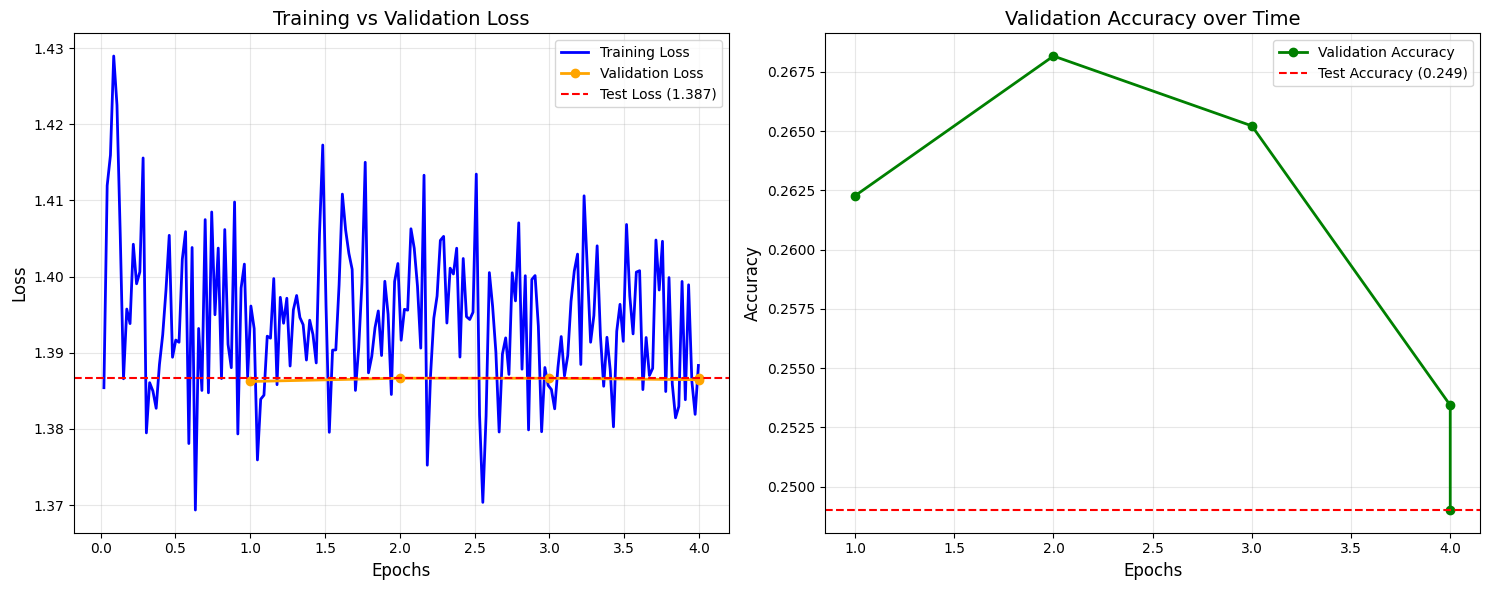

In [11]:
print("\n" + "="*40)
print("Test evaluation results")
print("="*40)
test_results = trainer.evaluate(tokenized_dataset["test"])

print(f"Test Loss:     {test_results['eval_loss']:.4f}")
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"Test Macro F1: {test_results['eval_f1_macro']:.4f}")
print(f"Test ECE:      {test_results['eval_ece']:.4f}")
print("="*40 + "\n")


# plots
history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['epoch'] for x in history if 'loss' in x]

val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
val_steps = [x['epoch'] for x in history if 'eval_loss' in x]
val_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# loss
ax1.plot(train_steps, train_loss, label='Training Loss', color='blue', linewidth=2)
if len(val_loss) > 0:
    ax1.plot(val_steps, val_loss, label='Validation Loss', color='orange', marker='o', linewidth=2)
    ax1.axhline(y=test_results['eval_loss'], color='red', linestyle='--', label=f"Test Loss ({test_results['eval_loss']:.3f})")
ax1.set_title('Training vs Validation Loss', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# accuracy
if len(val_acc) > 0:
    ax2.plot(val_steps, val_acc, label='Validation Accuracy', color='green', marker='o', linewidth=2)
    ax2.axhline(y=test_results['eval_accuracy'], color='red', linestyle='--', label=f"Test Accuracy ({test_results['eval_accuracy']:.3f})")
ax2.set_title('Validation Accuracy over Time', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
notebook_end_time = time.time()
elapsed = notebook_end_time - notebook_start_time
hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total notebook execution time: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")


Total notebook execution time: 00:10:03


In [13]:

if PUSH_TO_HUB:
    # push the fine-tuned model and tokenizer to the Hub
    trainer.push_to_hub(
        commit_message="Fine-tuned Bio_ClinicalBERT on MedQA",
        finetuned_from=config.MODEL_ID,
        dataset=config.DATASET_ID
    )
